In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Для фотографії не малюємо підписи кожного рядка й стовпця.
def show_images(items):
    fig, axes = plt.subplots(1, len(items), figsize=(4 * len(items), 4))
    for ax, (data, title) in zip(np.atleast_1d(axes), items):
        if data.ndim == 2:
            ax.imshow(data, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(data)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Початкова матриця:
 [[  0  40  80 120 160 200]
 [ 20  60 100 140 180 220]
 [ 30  70 110 150 190 230]
 [ 50  90 130 170 210 250]]
Змінена матриця:
 [[  0  40  80 120 160 200]
 [ 20  60 100 140   0 220]
 [ 30  70 110 150 190 230]
 [ 50  90 130 170 210 250]]
Форма: (4, 6)
Тип елементів: uint8
Кількість пікселів: 24
Обсяг даних пікселів: 24 байтів


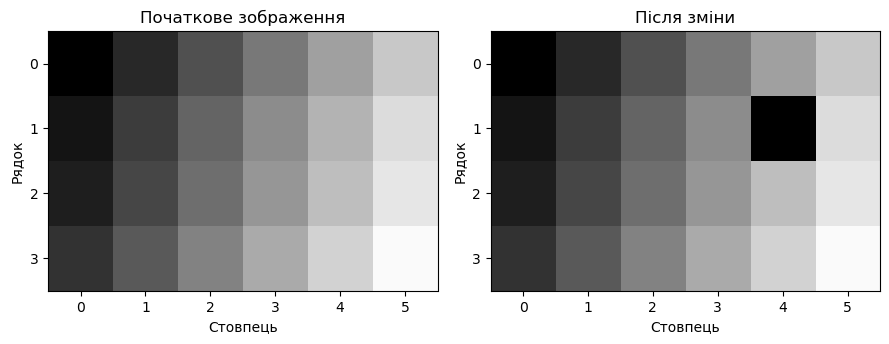

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Початкове зображення: кожне число задає яскравість одного пікселя.
G = np.array([
    [ 0, 40,  80, 120, 160, 200],
    [20, 60, 100, 140, 180, 220],
    [30, 70, 110, 150, 190, 230],
    [50, 90, 130, 170, 210, 250]
], dtype=np.uint8)

# Змінюйте ці параметри. Використовуйте цілі числа.
row = 1
col = 4
value = 0

if not (0 <= row < G.shape[0] and 0 <= col < G.shape[1]):
    raise ValueError("Індекс виходить за межі матриці")

if not 0 <= value <= 255:
    raise ValueError("Яскравість має бути від 0 до 255")

# Копія дозволяє порівнювати результат із незміненим оригіналом.
changed = G.copy()
changed[row, col] = value

print("Початкова матриця:\n", G)
print("Змінена матриця:\n", changed)
print("Форма:", G.shape)
print("Тип елементів:", G.dtype)
print("Кількість пікселів:", G.size)
print("Обсяг даних пікселів:", G.nbytes, "байтів")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, data, title in zip(
    axes,
    [G, changed],
    ["Початкове зображення", "Після зміни"]
):
    ax.imshow(
        data,
        cmap="gray",
        vmin=0,
        vmax=255,
        interpolation="nearest",
        origin="upper"
    )
    ax.set_xticks(range(data.shape[1]))
    ax.set_yticks(range(data.shape[0]))
    ax.set_xlabel("Стовпець")
    ax.set_ylabel("Рядок")
    ax.set_title(title)

plt.tight_layout()
plt.show()


Матриця R:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Матриця G:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Матриця B:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Форми каналів: (244, 250) (244, 250) (244, 250)


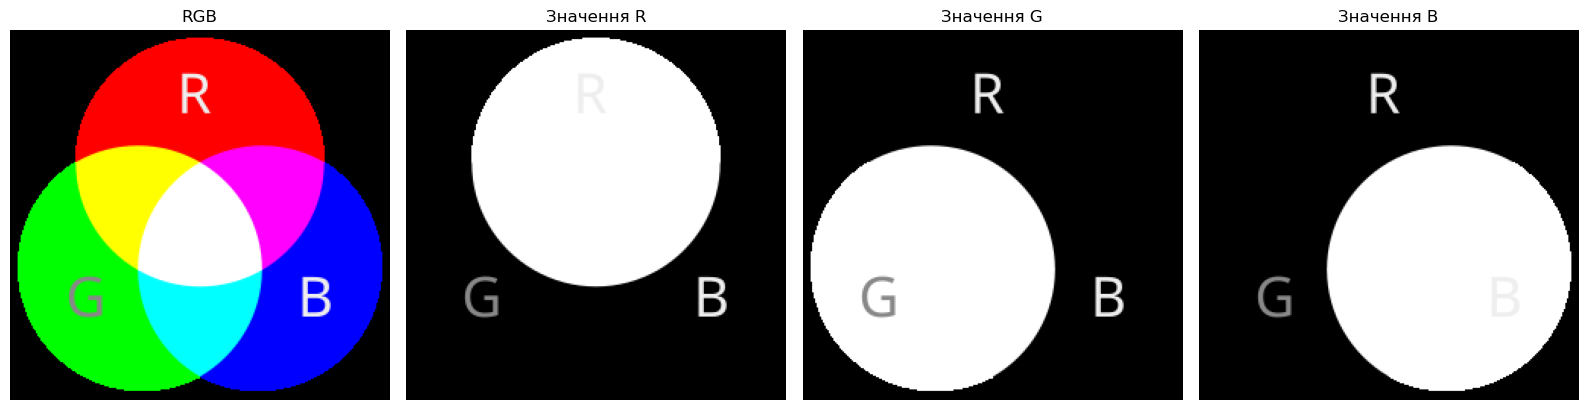

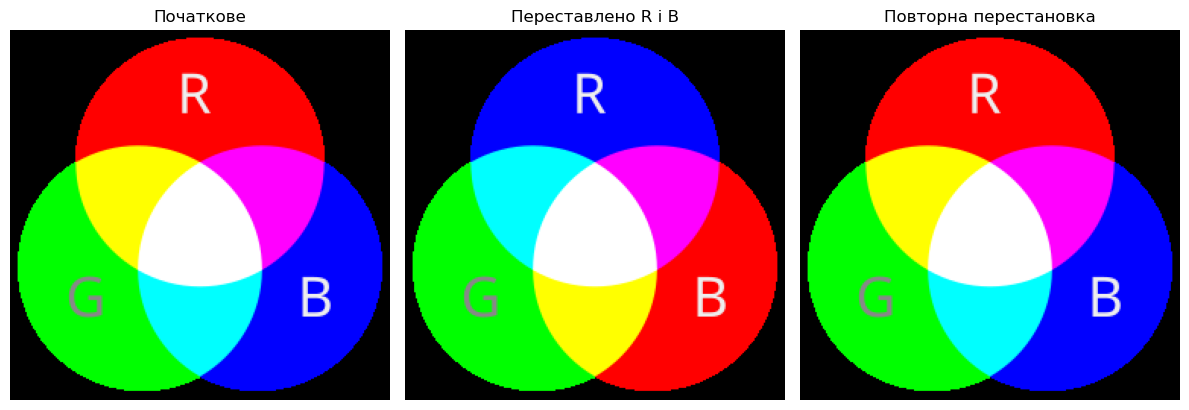

Відновлення точне: True


In [24]:
## img_pil = np.array(Image.open("02_RGB_Image.png").convert("RGB"), dtype=np.uint8)

img_pil = Image.open("01_Venn_diagram.png").convert("RGB")
image = np.array(img_pil)

red = image[:, :, 0]
green = image[:, :, 1]
blue = image[:, :, 2]

print("Матриця R:\n", red)
print("Матриця G:\n", green)
print("Матриця B:\n", blue)
print("Форми каналів:", red.shape, green.shape, blue.shape)

show_images([
    (image, "RGB"),
    (red, "Значення R"),
    (green, "Значення G"),
    (blue, "Значення B")
])

# Змінюємо порядок каналів; координати пікселів зберігаються.
swapped = image[:, :, [2, 1, 0]]
restored = swapped[:, :, [2, 1, 0]]

show_images([
    (image, "Початкове"),
    (swapped, "Переставлено R і B"),
    (restored, "Повторна перестановка")
])
print("Відновлення точне:", np.array_equal(image, restored))


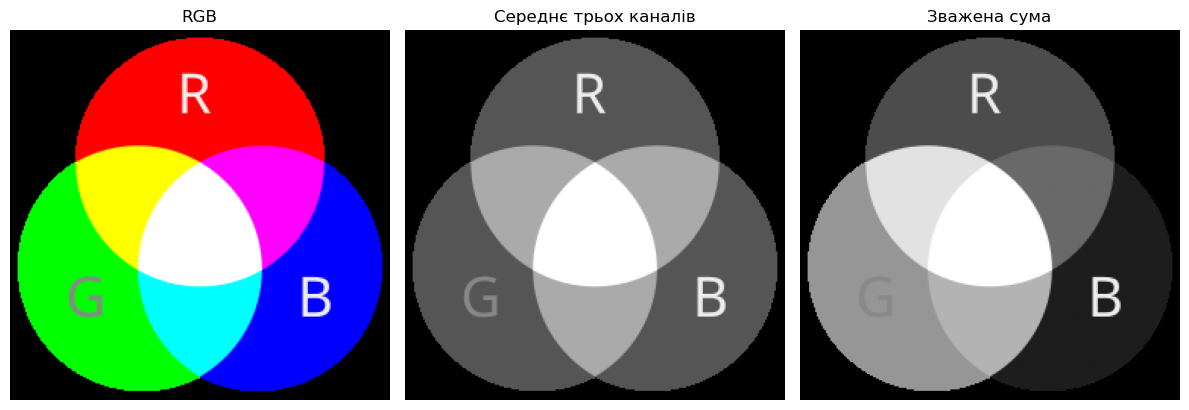

Піксель (0, 0): RGB=[0 0 0], середнє=0, зважене=0
Піксель (0, 1): RGB=[0 0 0], середнє=0, зважене=0
Піксель (0, 2): RGB=[0 0 0], середнє=0, зважене=0
Піксель (2, 2): RGB=[0 0 0], середнє=0, зважене=0
RGB shape = (244, 250, 3) dtype = uint8 size = 183000 nbytes = 183000
Середнє shape = (244, 250) dtype = uint8 size = 61000 nbytes = 61000
Зважене shape = (244, 250) dtype = uint8 size = 61000 nbytes = 61000


In [25]:
# Обчислюємо у float, щоб суми не переповнювали uint8.
work = image.astype(np.float64)

gray_mean_float = work.mean(axis=2)
weights = np.array([0.299, 0.587, 0.114])
gray_weighted_float = (work * weights).sum(axis=2)

# Обидва результати зберігаємо в одному типі для порівняння пам'яті.
gray_mean = np.clip(np.rint(gray_mean_float), 0, 255).astype(np.uint8)
gray_weighted = np.clip(np.rint(gray_weighted_float), 0, 255).astype(np.uint8)

show_images([
    (image, "RGB"),
    (gray_mean, "Середнє трьох каналів"),
    (gray_weighted, "Зважена сума")
])

for row, col in [(0, 0), (0, 1), (0, 2), (2, 2)]:
    print(
        f"Піксель ({row}, {col}): RGB={image[row, col]}, "
        f"середнє={gray_mean[row, col]}, "
        f"зважене={gray_weighted[row, col]}"
    )

for name, data in [
    ("RGB", image),
    ("Середнє", gray_mean),
    ("Зважене", gray_weighted)
]:
    print(
        name,
        "shape =", data.shape,
        "dtype =", data.dtype,
        "size =", data.size,
        "nbytes =", data.nbytes
    )
